# Track Embedding Clustering — UMAP + HDBSCAN + Title Validation

**Approach:**
- UMAP reduces track embeddings (clustering signal) to low-dimensional Euclidean space
- HDBSCAN clusters in UMAP space
- Playlist title embeddings serve as a validation signal only — they are never used for clustering

**Pipeline:**
1. Load embeddings → diagnostic norm check
2. UMAP on track embeddings (compare 10, 15, 20 dims; default 15)
3. Visualize UMAP layout
4. HDBSCAN clustering
5. Manual title-vs-cluster spot check
6. Per-cluster average pairwise cosine similarity of title embeddings

# Setup

In [7]:
from google.colab import drive
import os
drive.mount('/content/drive')

DRIVE_BASE           = "/content/drive/MyDrive/S2026/Spotify Playlist Data/Processed Data"
PROJECT_BASE         = "/content/drive/MyDrive/S2026/Spotify Playlist Data/Track vs Title"
EMBEDDINGS_PKL       = f"{DRIVE_BASE}/no_norm_embeddings.pkl"
CLUSTERS_OUTPUT_DIR  = f"{PROJECT_BASE}/umap_clusters"
REPO_DIR             = "/content/PlaylistClustering"

os.makedirs(CLUSTERS_OUTPUT_DIR, exist_ok=True)
print("Paths configured.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths configured.


In [8]:
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/siddmohanty111/PlaylistClustering.git {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

print("Repo ready:", REPO_DIR)

Already up to date.
Repo ready: /content/PlaylistClustering


In [9]:
%pip install -r {REPO_DIR}/requirements.txt
%pip install umap-learn hdbscan -q

In [10]:
cluster_alts_path = os.path.join(REPO_DIR, "clustering", "cluster_alts.py")

with open(cluster_alts_path, 'r') as f:
    content = f.read()

# Replace the incorrect import statement
content = content.replace('from skfuzzy import cmeans, cmeans_predict', 'import skfuzzy as fuzz')

# Replace function calls
content = content.replace('cmeans(', 'fuzz.cmeans(')
content = content.replace('cmeans_predict(', 'fuzz.cmeans_predict(')

with open(cluster_alts_path, 'w') as f:
    f.write(content)

print(f"Successfully modified {cluster_alts_path} to correct skfuzzy imports.")

Successfully modified /content/PlaylistClustering/clustering/cluster_alts.py to correct skfuzzy imports.


In [11]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    "cluster_alts",
    os.path.join(REPO_DIR, "clustering", "cluster_alts.py"),
)
cluster_alts = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cluster_alts)

print("cluster_alts loaded.")

cluster_alts loaded.


# Fix Pandas Version

In [ ]:
# # @title
# import subprocess, sys

# # Upgrade pandas to latest
# subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pandas", "-q"])

# # Restart runtime so the new pandas version is actually loaded
# import os
# os.kill(os.getpid(), 9)  # Forces a runtime restart — re-run all cells after this

# Imports

In [12]:
import os
import pickle
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import hdbscan
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Load Embeddings

In [ ]:
with open(EMBEDDINGS_PKL, 'rb') as f:
    data = pickle.load(f)

print("Full DataFrame shape:", data.shape)
print("Columns:", data.columns.tolist())
print(data.head())

Full DataFrame shape: (1000000, 4)
Columns: ['playlist_title', 'title_embedding', 'playlist_tracks', 'tracks_embedding']
     playlist_title                                    title_embedding  \
0        throwbacks  [0.011216641, 0.0033928205, 0.0034179217, -0.0...   
1  awesome playlist  [-0.08927007, -0.09901914, -0.0293388, -0.0857...   
2            korean  [-0.049768448, 0.05802605, 0.023397932, 0.0232...   
3               mat  [-0.023064643, 0.022735357, -0.058358226, 0.00...   
4               90s  [-0.04761651, 0.060712747, -0.03367506, -0.030...   

                                     playlist_tracks  \
0  [Lose Control (feat. Ciara & Fat Man Scoop), T...   
1  [Eye of the Tiger, Libera Me From Hell (Tengen...   
2  [Like You, GOOD (feat. ELO), Inferiority Compl...   
3  [Danse macabre, Piano concerto No. 2 in G Mino...   
4  [Tonight, Tonight, Wonderwall - Remastered, I ...   

                                    tracks_embedding  
0  [-0.03831684, 0.01738548, 0.007120576, 

In [ ]:
# Diagnostic: check whether embeddings are L2-normalized.
# SBERT and most sentence-transformer models output unit-norm vectors by default.
# If norms are all ~1.0, Euclidean distances concentrate around sqrt(2) regardless
# of dimensionality — explaining why PCA alone doesn't fix uniform memberships.
title_sample  = np.stack(data['title_embedding'].values[:200])
tracks_sample = np.stack(data['tracks_embedding'].values[:200])

title_norms  = np.linalg.norm(title_sample,  axis=1)
tracks_norms = np.linalg.norm(tracks_sample, axis=1)

print(f"Title  embedding norms — mean: {title_norms.mean():.4f}, std: {title_norms.std():.4f}")
print(f"Tracks embedding norms — mean: {tracks_norms.mean():.4f}, std: {tracks_norms.std():.4f}")
print()
if title_norms.std() < 0.01:
    print("⚠  Title embeddings appear L2-normalized (unit sphere).")
    print("   Euclidean distances will concentrate around √2 — this is why PCA alone")
    print("   does not fix uniform fuzzy memberships. UMAP is used below instead.")
else:
    print("Title embeddings are NOT unit-normalized — PCA alone may be sufficient.")

Title  embedding norms — mean: 1.0000, std: 0.0000
Tracks embedding norms — mean: 0.4587, std: 0.0408

⚠  Title embeddings appear L2-normalized (unit sphere).
   Euclidean distances will concentrate around √2 — this is why PCA alone
   does not fix uniform fuzzy memberships. UMAP is used below instead.


# UMAP — Track Embeddings

Fit UMAP on a 100k subsample of track embeddings, then batch-transform the full dataset.
We run three dimensionalities (10, 15, 20) so we can pick the best one before clustering.

In [ ]:
UMAP_FIT_SAMPLE = 100_000
TRANSFORM_BATCH = 10_000
UMAP_DIMS_TO_TRY = [10, 15, 20]
UMAP_DIM_DEFAULT = 15   # used downstream for clustering

rng = np.random.default_rng(42)

print("Stacking track embeddings...")
tracks_embeddings = np.stack(data['tracks_embedding'].values)
n_total = len(tracks_embeddings)
print(f"  Shape: {tracks_embeddings.shape}")

# Subsample for fitting
fit_idx = rng.choice(n_total, size=min(UMAP_FIT_SAMPLE, n_total), replace=False)
fit_data = tracks_embeddings[fit_idx]
print(f"  Fitting UMAP on {len(fit_idx):,} samples")

umap_results = {}   # dim -> (n_total, dim) array

for n_components in UMAP_DIMS_TO_TRY:
    print(f"\n── UMAP {n_components}d ──")
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=15,
        min_dist=0.0,
        metric='cosine',
        low_memory=True,
        random_state=42,
        verbose=False,
    )
    reducer.fit(fit_data)
    print(f"  Fit complete. Transforming {n_total:,} points in batches...")

    parts = []
    for start in range(0, n_total, TRANSFORM_BATCH):
        batch = tracks_embeddings[start : start + TRANSFORM_BATCH]
        parts.append(reducer.transform(batch))
        print(f"  {min(start + TRANSFORM_BATCH, n_total):,} / {n_total:,}", end="\r")
    print()

    umap_results[n_components] = np.vstack(parts)
    print(f"  Done. Output shape: {umap_results[n_components].shape}")

del tracks_embeddings
print("\nAll UMAP reductions complete.")

Stacking track embeddings...
  Shape: (1000000, 384)
  Fitting UMAP on 100,000 samples

── UMAP 10d ──


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Fit complete. Transforming 1,000,000 points in batches...
  1,000,000 / 1,000,000
  Done. Output shape: (1000000, 10)

── UMAP 15d ──


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Fit complete. Transforming 1,000,000 points in batches...
  1,000,000 / 1,000,000
  Done. Output shape: (1000000, 15)

── UMAP 20d ──


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Fit complete. Transforming 1,000,000 points in batches...
  1,000,000 / 1,000,000
  Done. Output shape: (1000000, 20)

All UMAP reductions complete.


# UMAP Dimension Selection Metrics

Three metrics help choose the best number of UMAP dimensions:

| Metric | What it measures | Want |
|---|---|---|
| **Trustworthiness** | Fraction of each point's true near-neighbours that are also near in UMAP space | High (→1) |
| **Continuity** | Fraction of UMAP near-neighbours that were also near in original space | High (→1) |
| **HDBSCAN noise fraction** | Fraction of points labelled as noise (−1) at a fixed `min_cluster_size` | Low |

Trustworthiness + continuity together form the **co-ranking** framework.
Higher is better for both. A large drop in either as dims decrease means that
dimensionality is too low to preserve neighbourhood structure faithfully.

In [ ]:
from sklearn.manifold import trustworthiness

# Run metrics on a small eval sample to keep it fast
EVAL_N = 5_000
eval_idx = rng.choice(n_total, size=EVAL_N, replace=False)

# Original space: use the already-stacked embeddings saved in data
original_sample = np.stack(data['tracks_embedding'].values[eval_idx])

rows = []
for dim, embedding in umap_results.items():
    umap_sample = embedding[eval_idx]

    tw = trustworthiness(original_sample, umap_sample, n_neighbors=15, metric='cosine')
    cont = trustworthiness(umap_sample, original_sample, n_neighbors=15, metric='euclidean')

    # Quick HDBSCAN probe
    probe = hdbscan.HDBSCAN(min_cluster_size=50, core_dist_n_jobs=-1)
    probe_labels = probe.fit_predict(umap_sample)
    noise_frac = (probe_labels == -1).mean()

    rows.append({
        'UMAP dims': dim,
        'Trustworthiness': round(tw, 4),
        'Continuity': round(cont, 4),
        'HDBSCAN noise %': round(noise_frac * 100, 2),
    })
    print(f"  {dim}d: trust={tw:.4f}  cont={cont:.4f}  noise={noise_frac:.2%}")

metrics_df = pd.DataFrame(rows).set_index('UMAP dims')
display(metrics_df)
print(f"\nDefault selected: {UMAP_DIM_DEFAULT}d  (change UMAP_DIM_DEFAULT above to override)")

  10d: trust=0.8109  cont=0.9335  noise=2.16%
  15d: trust=0.8087  cont=0.9346  noise=1.82%
  20d: trust=0.8104  cont=0.9347  noise=2.60%


,Trustworthiness,Continuity,HDBSCAN noise %
UMAP dims,,,
10,0.8109,0.9335,2.16
15,0.8087,0.9346,1.82
20,0.8104,0.9347,2.60



Default selected: 15d  (change UMAP_DIM_DEFAULT above to override)


# Visualize UMAP Layout (2D projection for plotting)

We run a separate 2D UMAP purely for visualization — the clustering uses
`UMAP_DIM_DEFAULT` dimensions, not 2.

Stacking track embeddings...
  Shape: (1000000, 384)
Fitting 2D UMAP for visualization...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  2D layout shape: (20000, 2)


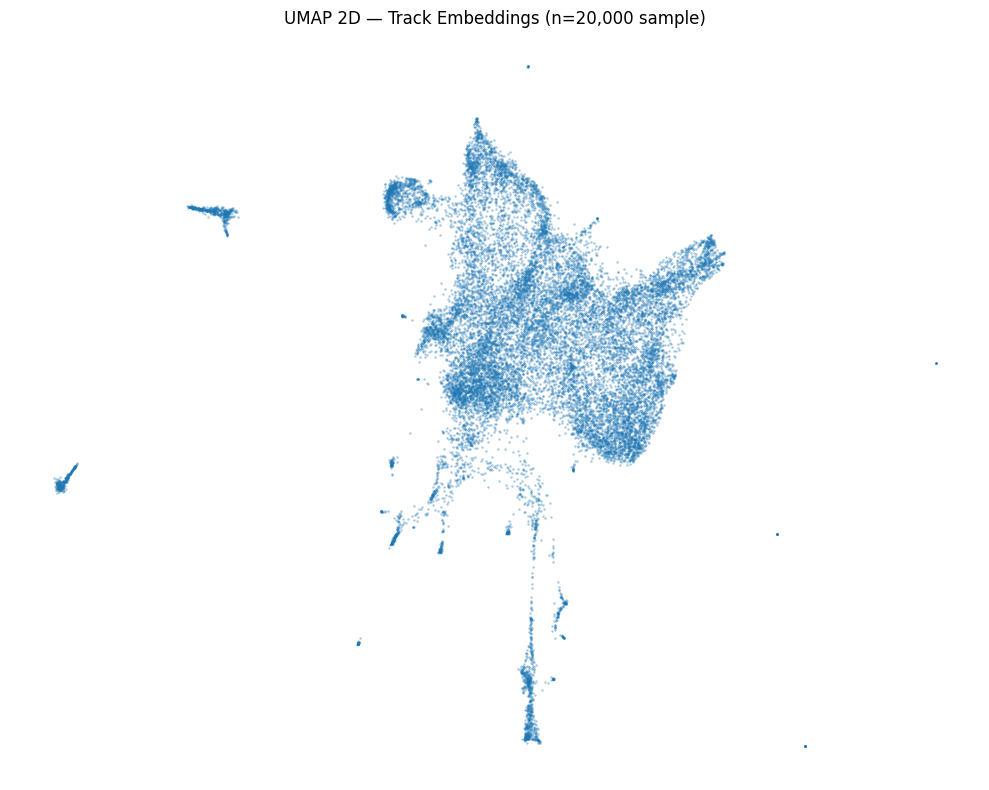

In [21]:
UMAP_FIT_SAMPLE = 100_000
TRANSFORM_BATCH = 10_000
UMAP_DIMS_TO_TRY = [10, 15, 20]
UMAP_DIM_DEFAULT = 15   # used downstream for clustering

rng = np.random.default_rng(42)

print("Stacking track embeddings...")
tracks_embeddings = np.stack(data['tracks_embedding'].values)
n_total = len(tracks_embeddings)
print(f"  Shape: {tracks_embeddings.shape}")

VIZ_SAMPLE = 20_000
viz_idx = rng.choice(n_total, size=VIZ_SAMPLE, replace=False)

print("Fitting 2D UMAP for visualization...")
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,   # slightly higher for cleaner scatter
    metric='cosine',
    low_memory=True,
    random_state=42,
    verbose=False,
)
umap_2d = reducer_2d.fit_transform(
    np.stack(data['tracks_embedding'].values[viz_idx])
)
print(f"  2D layout shape: {umap_2d.shape}")

plt.figure(figsize=(10, 8))
plt.scatter(umap_2d[:, 0], umap_2d[:, 1], s=3, alpha=0.4, linewidths=0)
plt.title(f"UMAP 2D — Track Embeddings (n={VIZ_SAMPLE:,} sample)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.axis('off')
plt.tight_layout()
plt.show()

### Load Saved UMAP and Cluster Data
Run this cell to load previously computed UMAP results and clustered data from disk.

In [13]:
import os
import pickle

output_path_data = os.path.join(CLUSTERS_OUTPUT_DIR, "hdbscan_clusters.pkl")
output_path_umap = os.path.join(CLUSTERS_OUTPUT_DIR, "umap_results.pkl")

if os.path.exists(output_path_data) and os.path.exists(output_path_umap):
    print("Loading saved data and UMAP results...")

    # Load main DataFrame (contains 'track_cluster' if HDBSCAN was already run)
    with open(output_path_data, 'rb') as f:
        data = pickle.load(f)
    print(f"Loaded clustered dataset from {output_path_data}")

    # Load UMAP projections
    with open(output_path_umap, 'rb') as f:
        umap_save_dict = pickle.load(f)

    umap_results = umap_save_dict['umap_results']
    umap_2d = umap_save_dict['umap_2d']
    UMAP_DIM_DEFAULT = umap_save_dict['UMAP_DIM_DEFAULT']
    print(f"Loaded UMAP results from {output_path_umap}")
else:
    print("Saved files not found. You will need to run the UMAP and HDBSCAN fitting cells above.")


Loading saved data and UMAP results...
Loaded clustered dataset from /content/drive/MyDrive/S2026/Spotify Playlist Data/Track vs Title/umap_clusters/hdbscan_clusters.pkl
Loaded UMAP results from /content/drive/MyDrive/S2026/Spotify Playlist Data/Track vs Title/umap_clusters/umap_results.pkl


# HDBSCAN Clustering on Track Embeddings

HDBSCAN is density-based: it finds clusters of arbitrary shape and marks low-density
points as noise (label `−1`). `min_cluster_size` is the primary knob — larger values
produce fewer, bigger clusters.

Note: `cluster_selection_method='eom'` (excess of mass) tends to produce more
clusters of varying size. Use `'leaf'` for more uniform cluster sizes.

In [14]:
embedding_for_clustering = umap_results[UMAP_DIM_DEFAULT]

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=200,
    min_samples=10,
    cluster_selection_method='eom',
    core_dist_n_jobs=-1,
    prediction_data=True,           # needed for soft cluster membership if wanted later
)
print(f"Running HDBSCAN on {embedding_for_clustering.shape} embedding...")
cluster_labels = clusterer.fit_predict(embedding_for_clustering)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
noise_frac  = (cluster_labels == -1).mean()
print(f"  Clusters found:  {n_clusters}")
print(f"  Noise points:    {noise_frac:.2%} of dataset")

# Attach labels to the main dataframe
data['track_cluster'] = cluster_labels

# Summary table
cluster_sizes = (
    data[data['track_cluster'] != -1]
    .groupby('track_cluster')
    .size()
    .rename('playlist_count')
    .sort_values(ascending=False)
    .reset_index()
)
print(f"\nCluster size summary (top 15):")
display(cluster_sizes.head(15))

Running HDBSCAN on (1000000, 15) embedding...
  Clusters found:  104
  Noise points:    63.42% of dataset

Cluster size summary (top 15):


,track_cluster,playlist_count
0,78,44621
1,34,39344
2,91,33104
3,14,32764
4,8,23153
5,95,17172
6,93,15987
7,16,14323
8,60,12232
9,40,9763


# HDBSCAN Parameter Tuning

Grid search over `min_cluster_size` ∈ {100, 200, 500, 1000} and
`cluster_selection_epsilon` ∈ [0, 2×UMAP_DIM_DEFAULT] in steps of 5.

**Selection criterion:** HDBSCAN's built-in `relative_validity_` score (a DBCV-based
relative validity index — higher is better). The best configuration is then used to
overwrite `cluster_labels` and `data['track_cluster']` for all downstream cells.

Grid search: 4 min_cluster_size × 11 epsilon = 44 runs
  min_cluster_size values : [100, 200, 500, 1000]
  epsilon values          : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

  [  1/44]  mcs=  100  eps=  0.0  clusters= 189  noise=68.41%  rel_val=0.1205
  [  2/44]  mcs=  100  eps=  1.0  clusters=  27  noise=0.05%  rel_val=0.0789
  [  3/44]  mcs=  100  eps=  2.0  clusters=  22  noise=0.03%  rel_val=0.0392
  [  4/44]  mcs=  100  eps=  3.0  clusters=  19  noise=0.02%  rel_val=0.0470
  [  5/44]  mcs=  100  eps=  4.0  clusters=  19  noise=0.02%  rel_val=0.0470
  [  6/44]  mcs=  100  eps=  5.0  clusters=  16  noise=0.02%  rel_val=0.1513
  [  7/44]  mcs=  100  eps=  6.0  clusters=  14  noise=0.02%  rel_val=0.1508
  [  8/44]  mcs=  100  eps=  7.0  clusters=  12  noise=0.02%  rel_val=0.0614
  [  9/44]  mcs=  100  eps=  8.0  clusters=  10  noise=0.02%  rel_val=0.1448
  [ 10/44]  mcs=  100  eps=  9.0  clusters=  10  noise=0.02%  rel_val=0.1448
  [ 11/44]  mcs=  100  eps= 10.0  clusters=   9  noise=0.02%

,min_cluster_size,cluster_selection_epsilon,n_clusters,noise_frac,relative_validity
0,1000,4,5,0.0025,0.3059
1,1000,3,5,0.0025,0.3059
2,100,5,16,0.0002,0.1513
3,100,6,14,0.0002,0.1508
4,100,8,10,0.0002,0.1448
5,100,9,10,0.0002,0.1448
6,200,9,4,0.0011,0.1440
7,200,8,4,0.0011,0.1440
8,1000,7,3,0.0015,0.1436
9,1000,8,3,0.0015,0.1436



Best configuration  →  min_cluster_size=1000  cluster_selection_epsilon=3.0  (rel_val=0.3059)
  Clusters found : 5
  Noise points   : 0.25% of dataset

Cluster size summary (top 15):


,track_cluster,playlist_count
0,2,976102
1,0,15203
2,1,2939
3,4,1925
4,3,1294


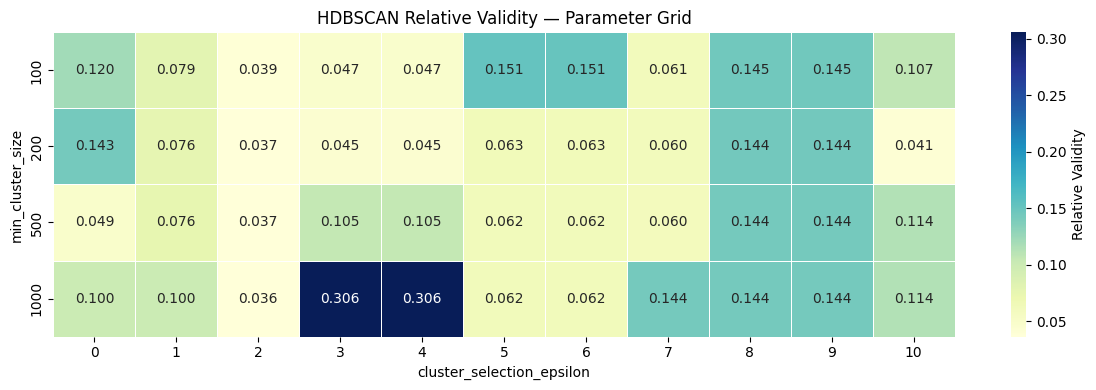

In [17]:
from itertools import product as _product

MIN_CLUSTER_SIZES   = [100, 200, 500, 1000]
EPSILON_STEP        = 1
epsilon_max         = 10                        # 30 when default is 15
EPSILONS            = [round(e * EPSILON_STEP, 1)
                       for e in range(int(epsilon_max / EPSILON_STEP) + 1)]   # [0, 5, 10, ..., 30]

embedding_for_clustering = umap_results[UMAP_DIM_DEFAULT]
total_runs = len(MIN_CLUSTER_SIZES) * len(EPSILONS)

print(f"Grid search: {len(MIN_CLUSTER_SIZES)} min_cluster_size × {len(EPSILONS)} epsilon "
      f"= {total_runs} runs")
print(f"  min_cluster_size values : {MIN_CLUSTER_SIZES}")
print(f"  epsilon values          : {EPSILONS}\n")

tuning_results = []

for i, (mcs, eps) in enumerate(_product(MIN_CLUSTER_SIZES, EPSILONS), 1):
    _c = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=10,
        cluster_selection_method='eom',
        cluster_selection_epsilon=eps,
        core_dist_n_jobs=-1,
        gen_min_span_tree=True
    )
    _labels = _c.fit_predict(embedding_for_clustering)
    _n      = len(set(_labels)) - (1 if -1 in _labels else 0)
    _noise  = (_labels == -1).mean()
    _rv     = float(_c.relative_validity_)

    tuning_results.append({
        'min_cluster_size'          : mcs,
        'cluster_selection_epsilon' : eps,
        'n_clusters'                : _n,
        'noise_frac'                : round(_noise, 4),
        'relative_validity'         : round(_rv, 4),
    })
    print(f"  [{i:3d}/{total_runs}]  mcs={mcs:5d}  eps={eps:5.1f}  "
          f"clusters={_n:4d}  noise={_noise:.2%}  rel_val={_rv:.4f}")

tuning_df = pd.DataFrame(tuning_results)

print("\n── Full results (sorted by relative validity) ──")
display(tuning_df.sort_values('relative_validity', ascending=False).reset_index(drop=True))

# ── Best configuration ──────────────────────────────────────────────────────
best_row = tuning_df.loc[tuning_df['relative_validity'].idxmax()]
best_mcs = int(best_row['min_cluster_size'])
best_eps = float(best_row['cluster_selection_epsilon'])

print(f"\nBest configuration  →  min_cluster_size={best_mcs}  "
      f"cluster_selection_epsilon={best_eps}  "
      f"(rel_val={best_row['relative_validity']:.4f})")

# Re-fit with best params (add prediction_data for downstream soft-membership use)
best_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=best_mcs,
    min_samples=10,
    cluster_selection_method='eom',
    cluster_selection_epsilon=best_eps,
    core_dist_n_jobs=-1,
    prediction_data=True,
    gen_min_span_tree=True
)
cluster_labels          = best_clusterer.fit_predict(embedding_for_clustering)
n_clusters              = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
noise_frac              = (cluster_labels == -1).mean()

print(f"  Clusters found : {n_clusters}")
print(f"  Noise points   : {noise_frac:.2%} of dataset")

# Update the main dataframe so all downstream cells stay consistent
data['track_cluster'] = cluster_labels

cluster_sizes = (
    data[data['track_cluster'] != -1]
    .groupby('track_cluster')
    .size()
    .rename('playlist_count')
    .sort_values(ascending=False)
    .reset_index()
)
print(f"\nCluster size summary (top 15):")
display(cluster_sizes.head(15))

# ── Heatmap: relative validity across the grid ──────────────────────────────
pivot = tuning_df.pivot(
    index='min_cluster_size',
    columns='cluster_selection_epsilon',
    values='relative_validity',
)
plt.figure(figsize=(12, 4))
sns.heatmap(
    pivot,
    annot=True, fmt='.3f', cmap='YlGnBu',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Relative Validity'},
)
plt.title('HDBSCAN Relative Validity — Parameter Grid')
plt.xlabel('cluster_selection_epsilon')
plt.ylabel('min_cluster_size')
plt.tight_layout()
plt.show()


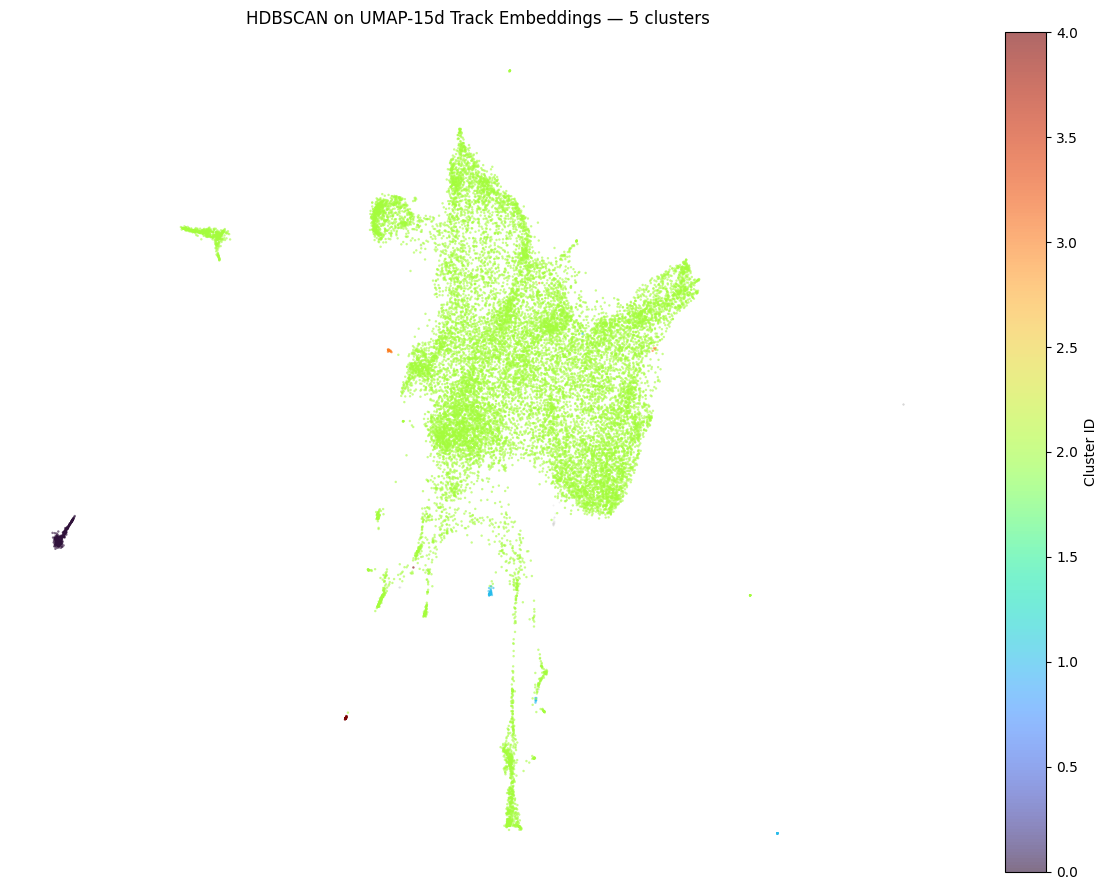

In [22]:
# Visualize clusters on the 2D layout
# Map the viz sample's cluster labels for colouring
viz_labels = cluster_labels[viz_idx]
noise_mask  = viz_labels == -1
cluster_mask = ~noise_mask

plt.figure(figsize=(12, 9))
plt.scatter(
    umap_2d[noise_mask, 0], umap_2d[noise_mask, 1],
    s=2, c='lightgrey', alpha=0.3, linewidths=0, label='Noise'
)
sc = plt.scatter(
    umap_2d[cluster_mask, 0], umap_2d[cluster_mask, 1],
    s=3, c=viz_labels[cluster_mask], cmap='turbo', alpha=0.6, linewidths=0
)
plt.colorbar(sc, label='Cluster ID')
plt.title(f"HDBSCAN on UMAP-{UMAP_DIM_DEFAULT}d Track Embeddings — {n_clusters} clusters")
plt.axis('off')
plt.tight_layout()
plt.show()

# Manual Spot-Check: Title vs Track Cluster Neighbours

Pick a few playlist titles below. For each, find the playlist in `data`,
then pull a random sample of other playlists in the same **track** cluster and
display their titles. This lets you judge by eye whether the track-based cluster
makes semantic sense relative to the title you chose as a reference.

In [ ]:
# ── Configuration ──────────────────────────────────────────────────────────
# Edit these titles to whatever you want to probe.
# The lookup is case-insensitive substring match, so partial names work.
PROBE_TITLES = [
    "chill vibes",
    "workout",
    "throwback",
]
NEIGHBOURS_TO_SHOW = 20   # how many cluster-mates to display per probe
# ───────────────────────────────────────────────────────────────────────────

# Drop noise points from lookup
clustered = data[data['track_cluster'] != -1].copy()

for probe in PROBE_TITLES:
    matches = clustered[clustered['playlist_title'].str.lower().str.contains(probe.lower())]
    if matches.empty:
        print(f'["{probe}"] — no exact match found, skipping.\n')
        continue

    # Pick the first match as the anchor
    anchor = matches.iloc[0]
    cluster_id = anchor['track_cluster']

    # Sample neighbours from the same track cluster (excluding the anchor itself)
    same_cluster = clustered[
        (clustered['track_cluster'] == cluster_id) &
        (clustered.index != anchor.name)
    ]
    sample = same_cluster.sample(min(NEIGHBOURS_TO_SHOW, len(same_cluster)), random_state=42)

    print(f'── Probe: "{anchor["playlist_title"]}"  →  Track cluster {cluster_id} '
          f'({len(same_cluster):,} playlists total) ──')
    display(sample[['playlist_title']].reset_index(drop=True))
    print()

── Probe: "chill vibes"  →  Track cluster 80 (8,761 playlists total) ──


,playlist_title
0,folk
1,work
2,love love love
3,easy
4,wanderlust
5,nostalgia
6,2012
7,ethereal
8,chill jams
9,stuff



── Probe: "workout2"  →  Track cluster 71 (1,294 playlists total) ──


,playlist_title
0,rap
1,workout
2,football
3,workout
4,gym workout
5,practice
6,motivate
7,pump up
8,workout
9,'till i collapse



── Probe: "throwbacks"  →  Track cluster 95 (17,171 playlists total) ──


,playlist_title
0,throwback
1,pre-game
2,gold
3,old mix
4,partayy
5,nostalgia
6,dance party
7,party
8,throwbacks
9,throwback


# Per-Cluster Title Coherence — Average Pairwise Cosine Similarity

For each track cluster, sample up to `TITLE_SAMPLE_PER_CLUSTER` title embeddings
and compute their average pairwise cosine similarity. High similarity means the
playlists in that cluster tend to have semantically similar titles — a good sign
that track content and playlist intent are aligned. Low similarity means the cluster
groups musically similar tracks that come from thematically diverse playlists.

Top 10 clusters by title coherence (most thematically consistent):


,cluster,n_playlists,sample_size,avg_pairwise_cosine_sim
7,7,231,200,0.8135
5,5,1925,200,0.7114
19,19,212,200,0.6985
16,16,14323,200,0.6961
25,25,363,200,0.6909
17,17,607,200,0.6746
20,20,583,200,0.6661
4,4,245,200,0.6465
45,45,232,200,0.5989
44,44,416,200,0.5954



Bottom 10 clusters by title coherence (most thematically diverse):


,cluster,n_playlists,sample_size,avg_pairwise_cosine_sim
79,79,735,200,0.2295
77,77,1426,200,0.2290
78,78,44621,200,0.2281
80,80,8762,200,0.2270
81,81,1703,200,0.2267
56,56,386,200,0.2251
62,62,4364,200,0.2243
51,51,3392,200,0.2232
40,40,9763,200,0.2218
49,49,246,200,0.2184


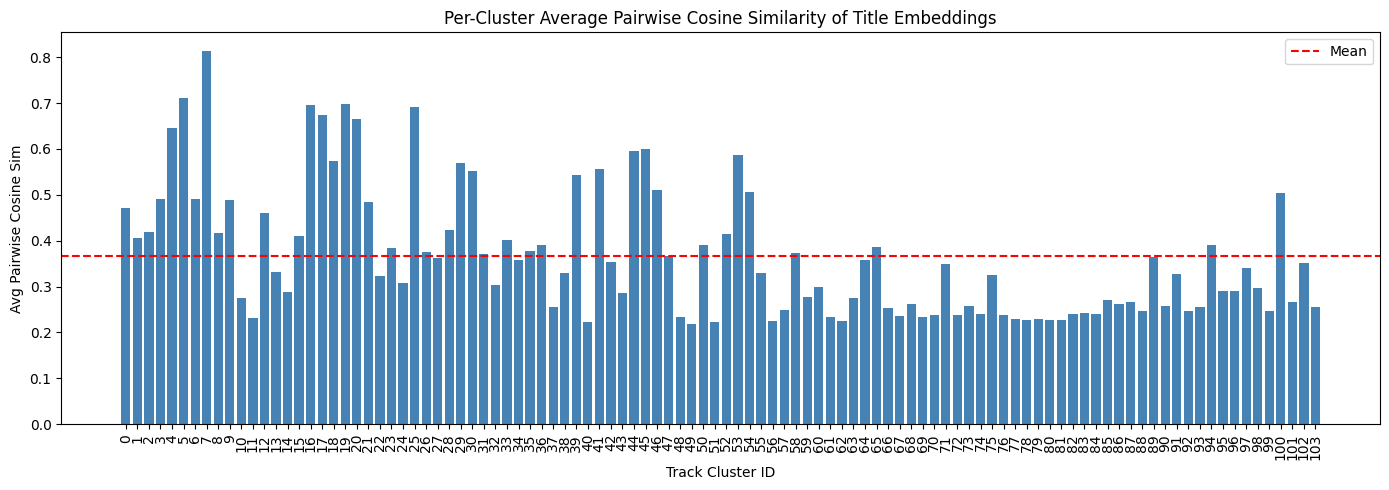


Overall mean: 0.3676
Std dev:      0.1414


In [ ]:
TITLE_SAMPLE_PER_CLUSTER = 200   # max title embeddings to sample per cluster

clustered = data[data['track_cluster'] != -1].copy()
cluster_ids = sorted(clustered['track_cluster'].unique())

results = []
for cid in cluster_ids:
    group = clustered[clustered['track_cluster'] == cid]
    sample = group.sample(min(TITLE_SAMPLE_PER_CLUSTER, len(group)), random_state=42)

    # Stack and L2-normalise title embeddings (cosine sim = dot product after normalisation)
    title_vecs = np.stack(sample['title_embedding'].values)
    title_vecs = normalize(title_vecs, norm='l2')

    # Average pairwise cosine similarity = (sum of all dot products - n) / (n*(n-1))
    # Efficiently computed as: (||sum||^2 - n) / (n*(n-1))
    n = len(title_vecs)
    if n < 2:
        avg_sim = np.nan
    else:
        dot_matrix = title_vecs @ title_vecs.T   # (n, n)
        avg_sim = (dot_matrix.sum() - n) / (n * (n - 1))  # exclude self-similarities

    results.append({
        'cluster': cid,
        'n_playlists': len(group),
        'sample_size': n,
        'avg_pairwise_cosine_sim': round(float(avg_sim), 4),
    })

coherence_df = pd.DataFrame(results).sort_values('avg_pairwise_cosine_sim', ascending=False)
print("Top 10 clusters by title coherence (most thematically consistent):")
display(coherence_df.head(10))
print("\nBottom 10 clusters by title coherence (most thematically diverse):")
display(coherence_df.tail(10))

# Visualise
plt.figure(figsize=(14, 5))
sorted_for_plot = coherence_df.sort_values('cluster')
plt.bar(sorted_for_plot['cluster'].astype(str), sorted_for_plot['avg_pairwise_cosine_sim'], color='steelblue')
plt.axhline(coherence_df['avg_pairwise_cosine_sim'].mean(), color='red', linestyle='--', label='Mean')
plt.title('Per-Cluster Average Pairwise Cosine Similarity of Title Embeddings')
plt.xlabel('Track Cluster ID')
plt.ylabel('Avg Pairwise Cosine Sim')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nOverall mean: {coherence_df['avg_pairwise_cosine_sim'].mean():.4f}")
print(f"Std dev:      {coherence_df['avg_pairwise_cosine_sim'].std():.4f}")

### Save Data
Save the clustered dataframe and the UMAP embeddings to disk for later use.

In [29]:
output_path_data = os.path.join(CLUSTERS_OUTPUT_DIR, "hdbscan_clusters_post_optimize.pkl")
output_path_umap = os.path.join(CLUSTERS_OUTPUT_DIR, "umap_results.pkl")

# 1. Save main DataFrame containing 'track_cluster'
with open(output_path_data, 'wb') as f:
    pickle.dump(data, f)
print(f"Saved clustered dataset to {output_path_data}")

# 2. Save UMAP projections (including the 2D layout for viz)
umap_save_dict = {
    'umap_results': umap_results,
    'umap_2d': umap_2d,
    'UMAP_DIM_DEFAULT': UMAP_DIM_DEFAULT
}
with open(output_path_umap, 'wb') as f:
    pickle.dump(umap_save_dict, f)
print(f"Saved UMAP results to {output_path_umap}")

Saved clustered dataset to /content/drive/MyDrive/S2026/Spotify Playlist Data/Track vs Title/umap_clusters/hdbscan_clusters_post_optimize.pkl
Saved UMAP results to /content/drive/MyDrive/S2026/Spotify Playlist Data/Track vs Title/umap_clusters/umap_results.pkl
